# [실습] Agent 구현

LangChain의 `create_agent`를 사용하여 가장 간단한 형태의 에이전트를 구현합니다.

## 학습 목표

- `create_agent`로 ReAct 에이전트를 구현하는 방법 학습
- TavilySearch + 다양한 커스텀 도구를 에이전트에 연결
- System Prompt 변경에 따른 에이전트 행동 변화 실험
- Checkpointer를 활용한 멀티턴 대화 구현

## 환경 설정

In [1]:
%pip install tzdata dotenv rich langchain langchain-openai langchain-tavily langgraph -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
import os
from langchain.messages import HumanMessage,AIMessage,SystemMessage

load_dotenv('.env', override=True)

if os.environ.get('OPENAI_API_KEY'):
    print('OpenAI API 키 설정 완료!')


OpenAI API 키 설정 완료!


---
## 1. ReAct Agent란?

ReAct(Reasoning + Acting)는 LLM이 생각(Reasoning)과 행동(Acting)을 번갈아 수행하는 패턴입니다.

```
사용자 질문
  → LLM이 어떤 도구를 사용할지 판단 (Reasoning)
  → 도구 실행 (Acting)
  → LLM이 결과를 분석하고 추가 행동 결정 (Reasoning)
  → (반복)
  → 최종 응답 생성
```

---
## 2. 도구(Tool) 불러오기

### 2-1. 검색 도구와 API 키

`web_search`는 Tavily(https://app.tavily.com) 검색 API를 사용합니다.   

Tavily Search는 월 1,000회의 무료 검색을 지원합니다.

`.env` 파일에 `TAVILY_API_KEY='tvly-...'`을 추가하세요.

In [4]:
import os
from dotenv import load_dotenv

load_dotenv('.env', override=True)

if os.environ.get('TAVILY_API_KEY'):
    print('Tavily API 키 설정 완료!')
else:
    print('TAVILY_API_KEY가 없습니다. web_search는 대체 도구로 동작합니다.')

Tavily API 키 설정 완료!


### 2-2. 표준 도구 불러오기

`tools.py`를 통해, 자주 사용할 도구를 불러오겠습니다.


In [6]:
from tools import (
    DEFAULT_TOOLS,
    web_search,
    calculator,
    get_current_datetime,
    text_analyzer,
    save_note,
    get_notes,
)

tools = DEFAULT_TOOLS
print(f'등록된 도구 ({len(tools)}개):')
for t in tools:
    print(f'  - {t.name}')

등록된 도구 (6개):
  - tavily_search
  - calculator
  - get_current_datetime
  - text_analyzer
  - save_note
  - get_notes


In [8]:
for t in tools:
    print(f'  - {t.name}\n{t.description}\n')
    print(t.args)

  - tavily_search
A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.

{'query': {'description': 'Search query to look up', 'title': 'Query', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specific websites (e.g., "Find climate data from nasa.gov")\n        2. The user mentions an organization or company without specifying the domain (e.g., "Find information about iPhones from Apple")\n\n        In both cases, you should determin

---
## 3. create_agent로 ReAct Agent 만들기

LangChain 1.x의 `create_agent`는 내부적으로 LangGraph 기반의 그래프를 생성하며, 도구 호출 루프를 자동으로 처리합니다.

Agent 타입: CompiledStateGraph


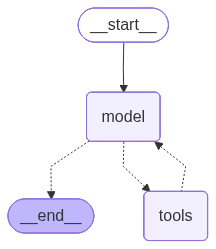

In [10]:
from langchain.agents import create_agent

agent = create_agent(
    'gpt-5.2',
    tools=tools,
    system_prompt='도구를 실행하기 전, 중간 과정을 간략히 설명하세요.'
)

# langgraph.prebuilt.create_react_agent는 Deprecated
# 바이브 코딩 시 참고해 주세요!

print(f'Agent 타입: {type(agent).__name__}')
agent

### 3-1. Agent 실행

Agent는 Tool 호출 + Tool 결과 + 다음 작업의 루프를 반복하며,    
HumanMessage --> AIMessage --> ToolMessage --> AIMessage --> ... 의 컨텍스트를 저장합니다.   

LLM과 동일하게 `invoke()`로 실행하며, 입력은 `messages` 키를 포함하는 dict입니다.

In [13]:
result = agent.invoke({
    'messages': [HumanMessage('안녕하세요? 선릉역 멀티캠퍼스 근처 맛집 추천해 주세요. 링크도 공유해주세요.')]
})

# 최종 응답
print(result['messages'][-1].text)

선릉역 **멀티캠퍼스(선릉로 428, 선릉역 2번 출구 쪽)** 기준으로 점심/저녁에 가기 좋은 곳들을 “종류별”로 추려 추천드릴게요. (아래는 위치·메뉴 확인하기 편하게 **지도/정보 링크**도 함께 첨부했습니다.)

## 1) 든든한 한식/국물
- **북창동순두부 선릉2호점** (순두부, 솥밥)  
  https://map.naver.com/p/search/%EB%B6%81%EC%B0%BD%EB%8F%99%EC%88%9C%EB%91%90%EB%B6%80%20%EC%84%A0%EB%A6%892%ED%98%B8%EC%A0%90
- **한강로칼국수 선릉점** (칼국수/만두 계열)  
  https://map.naver.com/p/search/%ED%95%9C%EA%B0%95%EB%A1%9C%EC%B9%BC%EA%B5%AD%EC%88%98%20%EC%84%A0%EB%A6%89%EC%A0%90

## 2) 고기/회식
- **하남돼지집 선릉1호점** (삼겹살, 점심특선도 있음)  
  https://map.naver.com/p/search/%ED%95%98%EB%82%A8%EB%8F%BC%EC%A7%80%EC%A7%91%20%EC%84%A0%EB%A6%89%201%ED%98%B8%EC%A0%90

## 3) 가벼운 점심(쌀국수/아시안)
- **포하임 선릉점** (쌀국수)  
  https://map.naver.com/p/search/%ED%8F%AC%ED%95%98%EC%9E%84%20%EC%84%A0%EB%A6%89%EC%A0%90

## 4) 근처 맛집 후보를 “더 많이” 보고 싶을 때(리스트/모음)
- 선릉역 근처 맛집 리스트형 포스팅(많이 나열되어 있어 고르기 좋음)  
  https://studyingengineer.tistory.com/1160

---

### 몇 가지 질문만 답해주시면 “취향 맞춤”으로 5곳만 더 정확히 골라드릴게요
1) 방문 목적: **혼밥/2~3인/회식** 중 어떤가요?  
2) 예산: **1만원 이하 / 1~1.5 / 상관없음** 

### 3-2. 메시지 흐름 분석

에이전트가 동작한 전체 과정을 메시지 흐름으로 확인할 수 있습니다.

In [15]:
def print_message_flow(messages):
    """에이전트의 메시지 흐름을 보기 좋게 출력"""
    for i, msg in enumerate(messages):
        msg_type = type(msg).__name__
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            calls = ', '.join([f"{tc['name']}({tc['args']})" for tc in msg.tool_calls])
            print(f'  [{i}] {msg_type}: tool_calls=[{calls}]')
        elif hasattr(msg, 'tool_call_id'):
            preview = msg.text
            print(f'  [{i}] {msg_type} ({msg.name}): {preview}')
        else:
            preview = msg.text  if len(msg.text) > 100 else msg.text
            print(f'  [{i}] {msg_type}: {preview}')

print_message_flow(result['messages'])

  [0] HumanMessage: 안녕하세요? 선릉역 멀티캠퍼스 근처 맛집 추천해 주세요. 링크도 공유해주세요.
  [1] AIMessage: tool_calls=[tavily_search({'query': '선릉역 멀티캠퍼스 근처 맛집', 'search_depth': 'advanced', 'include_images': False, 'topic': 'general'})]
  [2] ToolMessage (tavily_search): {"query": "선릉역 멀티캠퍼스 근처 맛집", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://m.blog.naver.com/a_lme/223166878223", "title": "멀티캠퍼스 선릉 구내식당 후기 우리집만두 버섯매운칼국수, 하남돼지 ...", "content": "본문 바로가기\n\n# 블로그\n\n## 카테고리 이동 Connecting the dots.\n\n검색\n\n선릉역 점심 혼밥 모음집 :: 멀티캠퍼스 선릉 구내식당 후기 우리집만두 버섯매운칼국수, 하남돼지집 점심특선, 포하임 양지쌀국수, 마라차이즈 후기, 마담밍 솔직후기\n\n프로필 \n\n2023. 7. 26. 19:16\n\n이웃추가\n\n 본문 폰트 크기 조정 가\n 공유하기\n URL복사\n 신고하기\n\n선릉역 멀티캠퍼스에서 교육을 받고 있는 요즘\n\n점심 때 선릉역 점심 맛집 도장깨기를 하고 다닌다\n\n사실 맛집은 별로 없는 것 같고\n\n#내돈내산 솔직 후기를 남겨보고자 한다.\n\n#멀티캠퍼스선릉맛집​​\n\n하남돼지집 선릉1호점\n\n서울특별시 강남구 선릉로86길 10\n\n\n\n먼저 하남돼지집 선릉1호점의 점심특선\n\n순두부찌개 + 비빔밥\n\n맛은 무난한데 순두부찌개에서 김치찌개 맛이 났다..\n\n가격은 9천원!\n\n이거 이외에도 다른 점심특선 메뉴들이 있는데 먹어보진 않았다.\n\n#하남돼지집선릉1호점점심특선순

## 스트리밍 헬퍼 라이브러리
전체를 스트리밍하여 아래와 같이 구성할 수도 있습니다.

In [16]:
from stream_utils import stream_print, stream_with_markdown

result = await stream_print(agent, '오늘 인공지능 관련 주요 뉴스 알려줘요')

최신 “오늘”자 주요 뉴스를 정확히 전달하려면 실시간 뉴스 검색으로 핵심 헤드라인을 수집한 뒤, 중복을 제거하고 영향도 기준으로 5~10개로 요약하겠습니다.
🔧 Tool 호출: tavily_search  {'query': '오늘 인공지능 주요 뉴스', 'search_depth': 'advanced', 'topic': 'news', 'time_range': 'day'}
✅ Tool 결과: {"query": "오늘 인공지능 주요 뉴스", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/208818-superhuman-acquires-gptzero-startup-specializing-in-ai-
최신 “오늘(최근 24시간)” 인공지능 주요 뉴스(해외 포함) 핵심만 추려서 정리했습니다.

1) **Superhuman, AI 생성물 탐지 스타트업 GPTZero 인수**
- AI로 작성된 글/과제 등을 판별하는 **AI 텍스트 탐지(진위·출처 확인)** 수요가 커지는 흐름 속에서 나온 M&A로 보도됐습니다.  
- 출처: Business Insider (2026-06-23) https://www.businessinsider.com/superhuman-acquires-gptzero-ai-authenticity-tools-2026-6

2) **미국 포함 ‘파이브 아이즈(Five Eyes)’ 정보동맹: “AI가 수개월 내 정부·기업 방어체계 뚫을 수준의 사이버 위협 가속” 경고**
- AI가 공격자의 진입장벽을 낮추고 공격 속도/복잡도를 높여 **사이버 리스크가 급격히 커질 수 있다**는 공동 경고가 핵심입니다.  
- 출처: CNN (2026-06-23) https://www.cnn.com/2026/06/23/world/ai-five-eyes-warning-cyber-threat-intl-hnk

원하시면 **(1) 한국 

In [21]:
# 마크다운 자동 렌더링
result = await stream_with_markdown(agent, '''오늘 프로야구 선발투수 매치업 알려줘. 5경기 10명이야. 
한국 소식은 topic을 general로 해야 해.
오늘 날짜를 검색어에 포함해서 찾아줘.
''')

오늘 날짜를 먼저 확인한 뒤, 그 날짜를 검색어에 포함해 KBO “선발투수 매치업”을 경기별로 찾아 교차 확인하겠습니다.

🔧 Tool 호출: `get_current_datetime` (인자: `{}`)

✅ 결과: 2026-06-24 14:01:20 (수요일)

🔧 Tool 호출: `tavily_search` (인자: `{'query': '2026-06-24 KBO 선발투수 매치업 5경기', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "2026-06-24 KBO 선발투수 매치업 5경기", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://namu.wiki/w/%EC%82%BC%EC%84%B1%20%EB%9D%BC%EC%9D%B4%EC%98%A8%EC%A6%88/2

🔧 Tool 호출: `tavily_search` (인자: `{'query': '2026-06-24 KBO 내일의 선발투수 6월24일(수)', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "2026-06-24 KBO 내일의 선발투수 6월24일(수)", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newsis.com/view/NISX20260623_0003680687", "title": "[KBO 내일의 선


---
오늘(2026-06-24) KBO **선발투수 매치업 (5경기 10명)** 입니다. (18:30)

- **잠실**: 삼성 **잭 오러클린** vs LG **앤더스 톨허스트**  
- **사직**: NC **커티스 테일러** vs 롯데 **엘빈 로드리게스**  
- **수원**: SSG **김민준** vs KT **맷 사우어**  
- **대전**: 두산 **최민석** vs 한화 **윌켈 에르난데스**  
- **고척**: KIA **양현종** vs 키움 **안우진**

출처: 뉴시스(2026-06-23 공개) 기사 및 동일 내용 재인용 기사 확인  
https://www.newsis.com/view/NISX20260623_0003680687  
https://www.topstarnews.net/news/articleView.html?idxno=16108801

---
## 4. 다양한 질문으로 Agent 실행하기

에이전트는 질문의 유형에 따라 적절한 도구를 선택하여 사용합니다.

### 4-1. 검색이 필요한 질문

In [23]:
result = await stream_with_markdown(agent, 'Anthropic이 만든, LLM Agent의 "Skills"에 대해 설명해줘. MCP와 뭐가 달라? Skill/MCP 표준 스펙을 바탕으로 설명해.')

최신 “Skills”/MCP 표준 문서에서 정의(무엇을 표준화하는지, 구성요소·프로토콜·보안 모델 등)를 확인한 뒤, 같은 축(목표/범위, 인터페이스, 배포/발견, 실행모델, 권한/격리)으로 비교해 정리하겠습니다.

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'Anthropic Skills specification LLM agent skills standard spec', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "Anthropic Skills specification LLM agent skills standard spec", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://agentskills.io/home", "title": "Agent

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'Agent Skills specification SKILL.md format sections frontmatter schema', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "Agent Skills specification SKILL.md format sections frontmatter schema", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://agentskills.io/specification

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'Model Context Protocol specification tools resources prompts transport JSON-RPC 2.0 authorization', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "Model Context Protocol specification tools resources prompts transport JSON-RPC 2.0 authorization", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://w

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'agentskills.io AGENTS.md router specification discovery behavior', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "agentskills.io AGENTS.md router specification discovery behavior", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://abvijaykumar.medium.com/deep-dive-

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'modelcontextprotocol.io specification tools/list resources/list prompts/list initialize capabilities roots sampling security', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "modelcontextprotocol.io specification tools/list resources/list prompts/list initialize capabilities roots sampling security", "follow_up_questions": null, "answer": null, "images": [], "re


---
(표준 문서 기준으로) **Agent Skills(Anthropic에서 시작해 공개 표준화된 “Skills”)**는 *에이전트가 특정 일을 “어떻게 수행할지”에 대한 절차적 노하우를 패키징해, 필요할 때만 컨텍스트에 로드*하도록 만든 **파일/디렉터리 포맷 표준**이고, **MCP(Model Context Protocol)**는 *에이전트(호스트/클라이언트)와 외부 기능·데이터를 제공하는 서버가 통신하는 방법*을 정한 **런타임 통신 프로토콜 표준**입니다.  
즉, Skills는 “지식/워크플로우를 담는 꾸러미”, MCP는 “도구/리소스를 호출하는 연결 규약”에 가깝습니다.

---

## 1) Agent Skills(“Skills”) 표준: 무엇을 표준화하나

### 핵심 목적
- 재사용 가능한 에이전트 능력을 **“스킬 디렉터리”**로 묶어 배포하고,
- 에이전트가 **점진적 로딩(progressive disclosure)** 방식으로
  - 시작 시에는 메타데이터만,
  - 필요해지면 SKILL.md 본문(절차/지침),
  - 필요 시 references/assets/scripts 같은 부속 파일
  을 추가 로드하게 하는 포맷을 정의합니다. (컨텍스트 절약이 목표)

### 최소 구성(스펙)
- 스킬은 **디렉터리**이며 최소 `SKILL.md`를 포함해야 함.
- `SKILL.md`는 **YAML frontmatter + Markdown 본문**으로 구성.
- Frontmatter 필드(스펙에 명시):
  - `name` (필수, 제약: 소문자/숫자/하이픈 등)
  - `description` (필수)
  - `license` (선택)
  - `compatibility` (선택: 환경 요구사항 설명)
  - `metadata` (선택: 임의 키-값)
  - `allowed-tools` (선택/실험적: 미리 승인된 도구 문자열)
- 선택 디렉터리(스펙):
  - `scripts/` : 에이전트가 실행할 수 있는 코드 번들(언어 지원은 런타임마다 다름)
  - `references/` : 필요할 때 읽을 심화 문서
  - `assets/` : 템플릿/데이터/이미지 등 정적 리소스

### 실행 모델(스펙이 전제하는 동작)
- **Discovery**: 에이전트는 시작 시 각 스킬의 `name`/`description`만 로드
- **Activation**: 관련 작업에서 스킬을 선택하면 `SKILL.md` 전체를 컨텍스트에 로드
- **Execution**: 지침을 따르고 필요하면 scripts 실행/참조 파일을 추가 로드

> 정리: Skills 표준은 “에이전트가 따라야 할 절차/규칙/예시(=프롬프트성 지식)”와 “부속 리소스”의 **패키징/구조/메타데이터/로딩 방식**을 규정합니다. 네트워크 프로토콜은 정의하지 않습니다.

---

## 2) MCP 표준: 무엇을 표준화하나

### 핵심 목적
- 호스트(에이전트 앱)와 외부 통합(서버)이 **표준 방식으로 연결**되어
  - 도구 실행(Functions)
  - 데이터/컨텍스트 제공(Resources)
  - 프롬프트 템플릿 제공(Prompts)
  를 할 수 있게 하는 **프로토콜**입니다.

### 프로토콜 골격(스펙)
- **JSON-RPC 2.0 기반** 메시징
- **stateful connection**, 초기화/세션/Capability negotiation(초기 `initialize`) 규정
- 서버가 제공할 수 있는 기능(스펙):
  - **Resources / Prompts / Tools**
- 클라이언트가 제공할 수 있는 기능(스펙):
  - **Sampling**(서버가 클라이언트에게 LLM 호출을 요청)
  - **Roots**(서버가 작업 경계/루트 URI 요청)
  - **Elicitation**(추가 정보 요청) 등
- 보안/신뢰 모델(스펙의 큰 축):
  - **도구 호출 전 사용자 명시적 동의**
  - **Sampling은 특히 human-in-the-loop 통제(승인/프롬프트 확인/편집 등) 권장/요구 사항들**
  - 서버가 프롬프트 전체를 마음대로 보지 못하도록 하는 의도(“protocol intentionally limits server visibility …” 같은 원칙)

> 정리: MCP는 “어떤 기능이 있다”를 넘어서 **그 기능을 원격/로컬 서버와 안전하게 협상하고 호출하는 통신 규약**을 정의합니다.

---

## 3) Skill vs MCP: 같은 축으로 비교

| 축 | Agent Skills(스킬) | MCP |
|---|---|---|
| 표준의 대상 | **패키징 포맷**(디렉터리, SKILL.md, references/scripts/assets) | **통신 프로토콜**(JSON-RPC, initialize, capabilities, methods) |
| 확장하는 것 | 모델/에이전트의 **절차적 수행 능력(“방법”)** | 에이전트의 **외부 접근 능력(“행동/데이터”)** |
| 발견/로드 | 시작 시 `name/description`만, 필요 시 전체 본문/리소스 로드(점진적) | 서버 연결 후 `initialize`로 capability 협상, `tools/list` 등으로 동적 발견 |
| 실행 단위 | “이 작업은 이 스킬 지침대로 하라” (주로 텍스트 지침 + 선택적 스크립트) | “이 툴/리소스를 이 스키마로 호출하라” (구조화된 요청/응답) |
| 보안/권한 | 스펙 레벨에선 포맷 중심. `allowed-tools`(실험적)로 “허용 도구” 힌트 제공 | 스펙에 **사용자 동의, human-in-the-loop, sampling 통제** 등 신뢰·안전 원칙이 강하게 포함 |
| 상호보완 | 스킬이 MCP 도구 사용 절차를 “문서화”할 수 있음 | MCP 서버가 프롬프트/워크플로를 제공하더라도 “프로젝트/조직 특화 절차”는 스킬로 묶어 배포 가능 |

---

## 4) 결론(언제 무엇을 쓰나)
- **“우리 팀/제품에서 X를 할 때의 정석 절차(체크리스트, 예시, 실수 방지 규칙, 실행 스크립트)를 에이전트가 필요할 때만 읽게 하고 싶다”** → Agent Skills
- **“에이전트가 Jira/Slack/DB/파일시스템/사내 API 같은 외부 능력을 표준 방식으로 붙이고, 안전하게 호출/승인/협상하고 싶다”** → MCP
- 실무에선 보통 같이 씁니다:  
  스킬(SKILL.md)에 “어떤 MCP 도구를 어떤 순서/파라미터로 호출할지, 에러 처리/재시도/검증은 어떻게 할지”를 절차로 적고, 실제 실행은 MCP로 합니다.

원하면, **(1) 스킬(SKILL.md) 예시 템플릿**과 **(2) 동일 기능을 MCP Tools/Prompts로 설계했을 때의 대응 관계**를 간단한 샘플로 같이 만들어 설명해줄게요.

### 4-2. 계산이 필요한 질문

In [24]:
result = await stream_with_markdown(agent, '2의 20승에 3의 30승을 곱하면 얼마인가요?')

계산기 도구로 \(2^{20} \times 3^{30}\) 값을 바로 계산하겠습니다.

🔧 Tool 호출: `calculator` (인자: `{'expression': '(2**20)*(3**30)'}`)

✅ 결과: 215892499727278669824


---
\(2^{20} \times 3^{30} = 215,892,499,727,278,669,824\) 입니다.

### 4-3. 텍스트 분석 질문

In [25]:
result = await stream_with_markdown(agent, '다음 문장의 글자 수와 단어 수를 분석해줘: "LangGraph는 LLM 기반의 복잡한 워크플로우를 그래프 구조로 정의하는 프레임워크입니다."')

주어진 문장을 그대로 넣어 글자 수/단어 수 통계를 도구로 계산하겠습니다.

🔧 Tool 호출: `text_analyzer` (인자: `{'text': 'LangGraph는 LLM 기반의 복잡한 워크플로우를 그래프 구조로 정의하는 프레임워크입니다.'}`)

✅ 결과: 텍스트 분석 결과:
  - 전체 글자 수: 52자
  - 공백 제외 글자 수: 44자
  - 단어 수: 9개
  - 문장 수: 1개


---
- 전체 글자 수: **52자**  
- 공백 제외 글자 수: **44자**  
- 단어 수: **9개**  
- 문장 수: **1개**

### 4-4. 메모 저장 및 조회

In [26]:
# 메모 저장
result = agent.invoke({
    'messages': [HumanMessage("오늘 할 일을 메모해줘. 제목은 '오늘 할 일'이고 내용은 'LangGraph 실습 완료하기'야.")]
})
print(f'[저장] {result["messages"][-1].text}')

[저장] 메모를 저장했어요.

- 제목: 오늘 할 일  
- 내용: LangGraph 실습 완료하기


In [27]:
# 메모 조회
result = agent.invoke({
    'messages': [HumanMessage('저장된 메모를 보여줘.')]
})
print(f'[조회] {result["messages"][-1].text}')

[조회] 저장된 메모 목록입니다:

- **오늘 할 일**: LangGraph 실습 완료하기


### 4-5. 여러 도구를 조합하는 질문

In [28]:
result = agent.invoke({
    'messages': [HumanMessage('오늘 날짜 알려주고, 올해가 며칠이 지났는지도 계산해줘.')]
})
print(result['messages'][-1].text)
print('\n--- 메시지 흐름 ---')
print_message_flow(result['messages'])

오늘 날짜: **2026-06-24 (수요일)**

올해(2026년) 경과 일수(1월 1일부터 오늘까지): **175일** 지났습니다.  
- 참고: 오늘(6/24)은 **올해의 176번째 날**입니다.

--- 메시지 흐름 ---
  [0] HumanMessage: 오늘 날짜 알려주고, 올해가 며칠이 지났는지도 계산해줘.
  [1] AIMessage: tool_calls=[get_current_datetime({})]
  [2] ToolMessage (get_current_datetime): 2026-06-24 14:06:20 (수요일)
  [3] AIMessage: tool_calls=[calculator({'expression': "( __import__('datetime').date(2026,6,24) - __import__('datetime').date(2026,1,1) ).days"})]
  [4] ToolMessage (calculator): 허용되지 않는 문자가 포함되어 있습니다: ( __import__('datetime').date(2026,6,24) - __import__('datetime').date(2026,1,1) ).days
  [5] AIMessage: tool_calls=[calculator({'expression': '31+28+31+30+31+24'})]
  [6] ToolMessage (calculator): 175
  [7] AIMessage: 오늘 날짜: **2026-06-24 (수요일)**

올해(2026년) 경과 일수(1월 1일부터 오늘까지): **175일** 지났습니다.  
- 참고: 오늘(6/24)은 **올해의 176번째 날**입니다.


---
## Agent의 구조화 출력

Agent 단계에서도, 출력의 포맷을 구조화할 수 있습니다.    
create_agent의 `response_format`은 Pydantic 스키마를 받습니다.   

Agent 단계의 response format은 LLM에 비해 더 유연한 장점을 갖습니다.    
만약 파싱이 깨지는 경우, Tool 결과로 오류 메시지를 반환하여, 모델이 이를 수정할 수 있도록 합니다.

In [29]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain.agents import create_agent

class SearchResult(BaseModel):
    """사용자의 질문에 대한 조사 결과"""
    summary: str = Field(description='한 문장 답변 요약')
    category: Literal['web_search_needed', 'web_search_not_needed'] = Field(
        description='''인터넷 검색이 필요했던 질문은 web_search_needed로 표시,
LLM 지식만으로 답할 수 있는 질문은 'web_search_not_needed'로 표시''')
    references: list[str] = Field(description='관련 참고 링크 리스트')
    
SYSTEM_PROMPT = """도구를 실행하기 전, 중간 과정을 간략히 설명하세요."""

search_agent = create_agent(
    'gpt-5.2',
    tools=[web_search],
    system_prompt=SYSTEM_PROMPT,
    response_format=SearchResult,
)

In [30]:
questions = [
    '2025년 노벨 물리학상 수상자가 누구였는지 찾아줘',
]

for q in questions:
    result = search_agent.invoke({'messages': [HumanMessage(q)]})['structured_response']

result

SearchResult(summary='2025년 노벨 물리학상은 John Clarke, Michel H. Devoret, John M. Martinis가 공동 수상했습니다.', category='web_search_needed', references=['https://www.nobelprize.org/uploads/2025/10/press-physicsprize2025.pdf', 'https://www.nobelprize.org/uploads/2025/10/popular-physicsprize2025-2.pdf', 'https://www.nobelprize.org/uploads/2025/10/Speakersmanuscript_Physics_2025_NobelPrizeLessons.pdf'])

In [31]:
from rich import print as rprint

rprint(result)

SearchResult(
    summary='2025년 노벨 물리학상은 John Clarke, Michel H. Devoret, John M. Martinis가 공동 수상했습니다.',
    category='web_search_needed',
    references=[
        'https://www.nobelprize.org/uploads/2025/10/press-physicsprize2025.pdf',
        'https://www.nobelprize.org/uploads/2025/10/popular-physicsprize2025-2.pdf',
        'https://www.nobelprize.org/uploads/2025/10/Speakersmanuscript_Physics_2025_NobelPrizeLessons.pdf'
    ]
)

---
## 5. 메모리(Checkpointer)를 사용한 멀티턴 대화

`InMemorySaver`를 사용하면 에이전트가 이전 대화를 기억하고 맥락을 유지할 수 있습니다.

`thread_id`로 서로 다른 대화 세션을 구분합니다.

In [32]:
from langgraph.checkpoint.memory import InMemorySaver

agent_with_memory = create_agent(
    'gpt-5.2',
    tools=tools,
    system_prompt='도구를 실행하기 전, 중간 과정을 간략히 설명하세요.',
    checkpointer=InMemorySaver()
)

# 동일한 thread_id로 대화 연속
config = {'configurable': {'thread_id': 'session-1'}}

In [33]:
# 첫 번째 대화
r1 = agent_with_memory.invoke(
    {'messages': [{'role': 'user', 'content': '안녕! 내 이름은 철수야.'}]},
    config=config
)
print(f'[턴 1] {r1["messages"][-1].text}')

[턴 1] 안녕, 철수! 반가워.  
오늘 무엇을 도와줄까?


In [34]:
# 두 번째 대화 - 이전 맥락 기억 확인
r2 = agent_with_memory.invoke(
    {'messages': [{'role': 'user', 'content': '내 이름이 뭐라고 했지?'}]},
    config=config
)
print(f'[턴 2] {r2["messages"][-1].text}')

[턴 2] 철수라고 했어.


In [35]:
r3 = await stream_with_markdown(agent_with_memory, '내 이름으로 삼행시 지어봐', config=config)

철: 철저히 웃음을 준비한  
수: 수많은 하루를 밝히는  
야: 야무진 철수!

In [36]:
# 다른 세션은 이전 대화를 모름
config_new = {'configurable': {'thread_id': 'session-2'}}

r3 = agent_with_memory.invoke(
    {'messages': [{'role': 'user', 'content': '내 이름이 뭐라고 했지?'}]},
    config=config_new
)
print(f'[새 세션] {r3["messages"][-1].text}')

[새 세션] 대화에서 이름을 말해준 적이 없어서, 제가 알 수 없어요.  
원하시면 이름을 알려주세요—앞으로 그 이름으로 불러드릴게요.


---
## 6. build_agent로 에이전트 스크립트 저장하기

지금까지 배운 에이전트를 배포할 수 있도록, 에이전트를 정의하는 스크립트를 구성합니다.

In [38]:
%%writefile build_agent.py
"""build_agent.py

에이전트를 한 곳에서 조립하는 팩토리입니다. 실습이 진행되며 도구, 미들웨어,
스킬, 메모리가 이 파일에 누적됩니다. 서비스 코드(예: Slack 봇)는 build_agent()만
호출해 항상 최신 에이전트를 받습니다.

지금 버전: 모델과 표준 도구.
"""

from __future__ import annotations

from langchain.agents import create_agent

from select_model import load_model
from tools import DEFAULT_TOOLS

DEFAULT_SYSTEM_PROMPT = (
    '당신은 유용한 AI 어시스턴트입니다. '
    '필요하면 도구를 사용하고, 도구를 실행하기 전 중간 과정을 간략히 설명하세요.'
)


def build_agent(model=None, tools=None, system_prompt=None, checkpointer=None):
    """현재까지 구성된 에이전트를 만들어 반환합니다.

    Args:
        model: chat model 또는 모델 이름. 생략 시 기본 모델을 로드합니다.
        tools: 도구 목록. 생략 시 tools.py의 DEFAULT_TOOLS를 씁니다.
        system_prompt: 시스템 프롬프트. 생략 시 기본값을 씁니다.
        checkpointer: 멀티턴 대화를 위한 체크포인터.
    """
    if model is None:
        model = load_model()
    if tools is None:
        tools = DEFAULT_TOOLS
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT
    return create_agent(
        model,
        tools=tools,
        system_prompt=system_prompt,
        checkpointer=checkpointer,
    )


Overwriting build_agent.py


`build_agent.py`는 다음과 같이 실행합니다.

In [39]:
from build_agent import build_agent

agent = build_agent()
result = await stream_with_markdown(agent, '오늘 날짜 알려주고, 올해가 며칠 지났는지 계산해줘')

🔧 Tool 호출: `get_current_datetime` (인자: `{}`)

✅ 결과: 2026-06-24 14:31:38 (수요일)

🔧 Tool 호출: `calculator` (인자: `{'expression': '(31+28+31+30+31+24)'}`)

✅ 결과: 175


---
오늘 날짜는 **2026년 6월 24일(수)** 입니다.

올해(2026년)는 오늘까지 **175일** 지났습니다. (1월 1일을 1일째로 계산)

---
## [실습] 나만의 ReAct Agent 만들기

아래 조건에 맞는 에이전트를 만들어보세요:

1. 새로운 도구를 1개 이상 추가
2. 에이전트에 적합한 시스템 프롬프트 작성
3. 여러 도구를 조합해야 하는 질문으로 테스트

In [40]:
# tool 문법으로 도구 정의
# bind_tools로 도구 연결
# invoke로 실행

import random
from langchain_core.tools import tool

@tool
def evaluate_impulse_buy(item_name: str, price_krw: int) -> str:
    """충동구매하려는 물건과 가격을 분석하여, 직관적인 대안 가치 비교와 함께 구매 충동을 늦출 수 있는 무작위 미션을 제안합니다.

    Args:
        item_name: 구매하려는 물건의 이름 (예: '기계식 키보드', '스마트 워치')
        price_krw: 물건의 가격 (원 단위, 정수)
    """
    if price_krw <= 0:
        return "가격이 0원 이하입니다. 무료라면 부담 없이 선택하셔도 좋습니다."

    # 대안 화폐 단위 정의 (단위명, 기준 가격)
    alternatives = [
        ("뜨끈한 뼈다귀 해장국", 10000),
        ("아이스 아메리카노", 4500),
        ("신라면 봉지면", 1000),
        ("넷플릭스 광고형 스탠다드 1개월 구독", 5500),
        ("최저임금 기준 노동 시간 (시간)", 9860)
    ]
    
    # 무작위로 비교 대상 선택
    selected_alt, unit_price = random.choice(alternatives)
    ratio = price_krw / unit_price
    
    # 구매 결정을 유예하기 위한 무작위 미션
    missions = [
        "장바구니에만 넣어두고 정확히 24시간 뒤에 다시 결제창을 열어보세요. 그때도 갖고 싶다면 필요한 물건일 확률이 높습니다.",
        "이 물건이 가진 치명적인 단점 혹은 사용 빈도가 낮을 이유를 메모장에 3가지만 적어보세요.",
        "즉시 물을 한 컵 마시고 가벼운 스트레칭을 1분간 하세요. 일시적인 쇼핑 도파민 분비를 줄이는 데 도움이 됩니다.",
        "집에 이 물건과 비슷하거나 대체할 수 있는 물건이 이미 있는지 방 안을 한 바퀴 둘러보며 찾아보세요."
    ]
    selected_mission = random.choice(missions)
    
    # 결과 포맷팅
    result = (
        f"💸 [{item_name}] 소비 제어 분석 결과\n"
        f"- 입력 가격: {price_krw:,}원\n"
        f"- 체감 물가 비교: 이 금액은 '{selected_alt}' 약 {ratio:.1f}개(시간)에 해당하는 가치입니다.\n"
        f"- 추천 미션: {selected_mission}"
    )
    return result


# 도구 실행 테스트
print(evaluate_impulse_buy.invoke({'item_name': '노이즈 캔슬링 헤드폰', 'price_krw': 280000}))

💸 [노이즈 캔슬링 헤드폰] 소비 제어 분석 결과
- 입력 가격: 280,000원
- 체감 물가 비교: 이 금액은 '아이스 아메리카노' 약 62.2개(시간)에 해당하는 가치입니다.
- 추천 미션: 집에 이 물건과 비슷하거나 대체할 수 있는 물건이 이미 있는지 방 안을 한 바퀴 둘러보며 찾아보세요.


In [41]:
import random
from langchain_core.tools import tool

@tool
def unconventional_perspective(statement: str) -> str:
    """입력된 사실, 수치, 혹은 상황에 대해 예상치 못한 페르소나의 관점으로 재미있는 피드백을 제공합니다.
    검색 결과나 계산 결과 등을 입력하여 새로운 관점을 얻을 때 유용합니다.

    Args:
        statement: 분석할 내용이나 수치 정보 (예: '서울에서 부산까지 KTX 요금은 59,800원이다')
    """
    if not statement.strip():
        return "분석할 내용이 비어 있습니다."

    # 다양한 관점을 가진 페르소나와 반응 정의
    personas = [
        {
            "role": "🏋️ 단호한 헬스 트레이너",
            "feedback": f"'{statement}'라니요... 혹시 그 생각이나 계산을 하느라 의자에 오래 앉아 계셨던 건 아니겠죠? 뇌 활동도 좋지만 하체 근육 손실이 우려됩니다. 지금 당장 일어나 스쿼트 15회 하고 다시 검토하십시오!"
        },
        {
            "role": "📜 조선시대 유학자",
            "feedback": f"참으로 눈부신 정보와 계산의 시대이군요. 허나 '{statement}'라는 사실이 부모님께 효도하고 마음의 평정을 찾는 유교적 덕목보다 중요하겠습니까? 잠시 마음을 가라앉히고 도리를 생각해보시지요."
        },
        {
            "role": "🍃 극단적 미니멀리스트",
            "feedback": f"'{statement}'에 대해 고민하고 수치를 계산하는 것 자체가 뇌의 에너지를 낭비하는 일일 수 있습니다. 삶을 더 단순하게 만드세요. 그것 없이도 살 수 있는 방법이 분명히 존재합니다."
        },
        {
            "role": "💰 냉혹한 투자 분석가",
            "feedback": f"그렇군요. 그렇다면 '{statement}'를 통해 얻을 수 있는 기대 수익률(ROI)이나 기회비용은 검토해보셨습니까? 단순한 지식 습득이나 소비에 머문다면 자산 관리 관점에서는 아쉬운 결정입니다."
        },
        {
            "role": "🛸 22세기 미래학자",
            "feedback": f"현시점 인류의 기술과 상식으로는 '{statement}'가 중요해 보일 것입니다. 하지만 머지않아 인공지능과 우주 개척이 일상화될 미래 관점에서 보면 이는 아주 사소한 해프닝입니다. 더 넓은 지평선에서 바라보십시오."
        }
    ]
    
    # 무작위로 페르소나 선택
    selected = random.choice(personas)
    
    result = (
        f"💡 [독특한 관점 피드백]\n"
        f"- 입력된 정보: {statement}\n"
        f"- 분석 페르소나: {selected['role']}\n"
        f"- 한마디: {selected['feedback']}"
    )
    return result


# 도구 직접 실행 테스트 (예: 검색과 계산을 통해 도출된 결과를 입력)
print(unconventional_perspective.invoke({'statement': '한 달 동안 매일 커피를 마시면 약 135,000원이 소비된다'}))

💡 [독특한 관점 피드백]
- 입력된 정보: 한 달 동안 매일 커피를 마시면 약 135,000원이 소비된다
- 분석 페르소나: 💰 냉혹한 투자 분석가
- 한마디: 그렇군요. 그렇다면 '한 달 동안 매일 커피를 마시면 약 135,000원이 소비된다'를 통해 얻을 수 있는 기대 수익률(ROI)이나 기회비용은 검토해보셨습니까? 단순한 지식 습득이나 소비에 머문다면 자산 관리 관점에서는 아쉬운 결정입니다.


In [48]:
tools = DEFAULT_TOOLS + [unconventional_perspective, evaluate_impulse_buy]

# TODO: 에이전트를 생성하세요
my_agent = create_agent(
    'gpt-5.2',
    tools=tools,
    system_prompt='''툴을 실행할 때마다 중간 과정을 간략히 설명하세요. 
정확한 수치나 정보가 필요한 문제는 항상 검색을 먼저 수행하고
사용자의 의견이나 제안은 충동구매 분석기와 다각도 분석기 도구로 평가하세요.
'''
)

await stream_with_markdown(my_agent,'''GLM-5 모델을 회사에서 돌리기 위해
H100을 몇 대 사려고 해, GPU 가격 괜찮겠지? ''')

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'GLM-5 model parameters size requirements H100 number of GPUs', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "GLM-5 model parameters size requirements H100 number of GPUs", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nxcode.io/resources/news/glm-5-ope

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'NVIDIA H100 80GB SXM price 2025 2026 per GPU', 'search_depth': 'advanced', 'topic': 'finance'}`)

🔧 Tool 호출: `evaluate_impulse_buy` (인자: `{'item_name': 'NVIDIA H100 (for running GLM-5 in-house)', 'price_krw': 50000000}`)

✅ 결과: 💸 [NVIDIA H100 (for running GLM-5 in-house)] 소비 제어 분석 결과
- 입력 가격: 50,000,000원
- 체감 물가 비교: 이 금액은 '최저임금 기준 노동 시간 (시간)' 약 5071.0개(시간)에 해당하는 가치입니다.
- 추천 미션: 즉시 물을 한 컵 마시고 가벼운 스트레칭을 1분간 하세요. 일시적인 쇼핑 도파민 분비

✅ 결과: {"query": "NVIDIA H100 80GB SXM price 2025 2026 per GPU", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/sectors/technology/articles/datavaul


---
GLM-5를 “회사에서 직접” 돌리는 관점이면, **H100을 몇 대 살지/가격이 괜찮은지**를 먼저 두 갈래로 나눠 봐야 합니다: **(1) 기술적으로 H100으로 가능한 구성인지** vs **(2) 구매가 ‘합리적’인지(대안 대비)**.

## 1) GLM-5는 H100 몇 대로 되나? (현실적인 결론)
검색 기준으로 GLM-5는 **총 744B(MoE, 토큰당 활성 ~40B)** 급으로 알려져 있고, 배포/서빙 쪽 안내에서 **“풀 모델 로딩에 8× B200(180GB)급이 필요”** 같은 언급이 있습니다. 즉, **H100 80GB 여러 장으로도 ‘어떻게든’은 가능할 수 있지만, ‘여유 있게/권장 구성’과는 거리가 멉니다.**  
또 다른 자료에서는 “대략 8× A100 80GB 또는 동급” 같은 주장도 있는데, 출처/조건(정밀도, 양자화, KV cache, 컨텍스트 길이, 텐서병렬/파이프라인 등)에 따라 편차가 큽니다.

**실무적으로는 이렇게 정리하는 게 안전합니다.**
- **200K 컨텍스트/고동시성/안정 운영까지 포함하면**: H100만으로 “몇 장이면 끝”이라고 말하기 어렵고, **B200급(또는 그에 준하는 VRAM/대역폭)**을 전제로 한 가이드가 보입니다.
- **FP8(또는 더 공격적인 양자화) + 컨텍스트를 낮추고 + 동시성을 낮추면**: H100 다수 장으로 **서빙 ‘가능’ 영역**이 열릴 수 있음.
- 그래서 “H100 몇 대?”는 질문이 아니라 **목표 SLO(동시 사용자, TPS, 지연), 컨텍스트 길이, 정밀도/양자화, 배치 전략**을 먼저 정해야 산정 가능합니다.

원하면 내가 **목표치**(예: 동시 20, 입력 8k/출력 1k, p95 2s 등)만 받아서 “H100 80GB 기준 대략 몇 장 + 왜 그렇게 되는지(메모리/KV 캐시/통신)”로 추정 프레임을 잡아줄게요.

## 2) “GPU 가격 괜찮겠지?” → 지금은 가격부터 묻기보다 *구매가 맞는지*가 먼저
정확한 H100 실구매가는 **(SXM vs PCIe, 80GB vs 94GB, 신품/중고, 공급 계약, 서버 포함 여부)**에 따라 크게 달라서, 방금 검색에선 **신뢰할 만한 ‘단일 가격’ 근거를 바로 못 잡았습니다**(재판매/계약가 편차가 커서 공개 레퍼런스가 잘 안 잡히는 편).

대신 의사결정 관점에서 핵심은 이거예요:
- **GLM-5가 B200급 8장 권장/필요**로 안내되는 쪽 자료가 있다면, H100을 여러 대 사는 건 **“가격이 괜찮냐” 이전에 “아키텍처 선택이 맞냐”** 문제가 됩니다.  
- H100을 사더라도, 보통은 **GPU만**이 아니라 **NVLink 토폴로지(HGX급), CPU/메모리, 스토리지, 네트워크(IB/200G 이상), 전력/냉각, 랙** 비용이 같이 붙습니다. GPU 단가만 보고 “괜찮다” 판단하면 예산이 터지기 쉽습니다.

## 3) 충동구매(과잉투자) 관점 체크
도구로 “H100 1대 = 5,000만원” 가정으로 충동구매 분석을 돌려보면, 이건 개인 소비 미션 수준이 아니라 **구매 의사결정 게이트를 세워야 하는 금액**으로 나옵니다(최저임금 노동시간으로 환산 시 매우 큰 규모).  
즉, 지금 단계에선 **바로 ‘몇 대 산다’로 가기보다** 아래 체크리스트로 한 번 잠그는 게 좋습니다.

## 4) 다음 질문 6개만 답해주면, “H100 몇 대/대안이 더 싼지”를 좁혀줄게요
1) 목적: **추론만**? **파인튜닝/학습도**?  
2) 목표 컨텍스트: **200K를 꼭 써야 함**? 보통 **8K/32K/128K** 중 어디?  
3) 동시성/트래픽: 최대 동시 요청, 목표 TPS, p95 지연?  
4) 정밀도: FP16/BF16, FP8, INT8/4 같은 **양자화 허용 여부**?  
5) 형태: **온프레미스 HGX 섀시**까지 살 계획? 아니면 PCIe 서버 여러 대?  
6) 예산 범위(서버/네트워크/랙 포함 총액)와, 클라우드/리스도 가능한지?

원하면 위 답변 받는 즉시,
- **(A) H100 온프레미스 최소/권장 구성(서버 포함)**  
- **(B) B200/H200/클라우드 임대 대비 TCO**  
- **(C) GLM-5 대신 더 작은 모델/증류로 목표 달성**  
이렇게 3안으로 비교표 만들어 줄게요.

'GLM-5를 “회사에서 직접” 돌리는 관점이면, **H100을 몇 대 살지/가격이 괜찮은지**를 먼저 두 갈래로 나눠 봐야 합니다: **(1) 기술적으로 H100으로 가능한 구성인지** vs **(2) 구매가 ‘합리적’인지(대안 대비)**.\n\n## 1) GLM-5는 H100 몇 대로 되나? (현실적인 결론)\n검색 기준으로 GLM-5는 **총 744B(MoE, 토큰당 활성 ~40B)** 급으로 알려져 있고, 배포/서빙 쪽 안내에서 **“풀 모델 로딩에 8× B200(180GB)급이 필요”** 같은 언급이 있습니다. 즉, **H100 80GB 여러 장으로도 ‘어떻게든’은 가능할 수 있지만, ‘여유 있게/권장 구성’과는 거리가 멉니다.**  \n또 다른 자료에서는 “대략 8× A100 80GB 또는 동급” 같은 주장도 있는데, 출처/조건(정밀도, 양자화, KV cache, 컨텍스트 길이, 텐서병렬/파이프라인 등)에 따라 편차가 큽니다.\n\n**실무적으로는 이렇게 정리하는 게 안전합니다.**\n- **200K 컨텍스트/고동시성/안정 운영까지 포함하면**: H100만으로 “몇 장이면 끝”이라고 말하기 어렵고, **B200급(또는 그에 준하는 VRAM/대역폭)**을 전제로 한 가이드가 보입니다.\n- **FP8(또는 더 공격적인 양자화) + 컨텍스트를 낮추고 + 동시성을 낮추면**: H100 다수 장으로 **서빙 ‘가능’ 영역**이 열릴 수 있음.\n- 그래서 “H100 몇 대?”는 질문이 아니라 **목표 SLO(동시 사용자, TPS, 지연), 컨텍스트 길이, 정밀도/양자화, 배치 전략**을 먼저 정해야 산정 가능합니다.\n\n원하면 내가 **목표치**(예: 동시 20, 입력 8k/출력 1k, p95 2s 등)만 받아서 “H100 80GB 기준 대략 몇 장 + 왜 그렇게 되는지(메모리/KV 캐시/통신)”로 추정 프레임을 잡아줄게요.\n\n## 2) “GPU 가격 괜찮겠지?” → 지금은 가격부터 묻기보다 *구매가 맞는지*가 먼저\n정확한 H100 실구매가는 **(

---
## 정리

이번 실습에서 학습한 내용을 정리합니다.

- ReAct 패턴: LLM이 생각(Reasoning)과 행동(Acting)을 반복하며 문제를 해결하는 패턴
- create_agent: LangChain 1.x의 표준 에이전트 생성 API. 내부적으로 LangGraph 기반 그래프 구성
- 표준 도구: web_search(검색), calculator(계산), get_current_datetime(날짜/시간), text_analyzer(텍스트 분석), save_note/get_notes(메모)를 import해 활용
- System Prompt: 에이전트의 성격과 행동 방식을 결정하는 핵심 요소
- Checkpointer: `InMemorySaver`를 사용하면 `thread_id` 기반의 멀티턴 대화가 가능
- 메시지 흐름: `HumanMessage -> AIMessage(tool_calls) -> ToolMessage -> AIMessage(응답)` 패턴이 반복